# Import Data

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns

from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
import matplotlib.pyplot as plt
from mgwr.sel_bw import Sel_BW
from mgwr.sel_bw import Sel_BW

import statsmodels as stats
from scipy.spatial.distance import cdist
import libpysal
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot, plot_local_autocorrelation
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import scipy.stats as stats
from linearmodels.panel import PanelOLS, PooledOLS
from statsmodels.stats.diagnostic import lilliefors
import json
import os
from splot.esda import plot_moran, plot_local_autocorrelation
from libpysal.weights import Queen
from statsmodels.stats.outliers_influence import variance_inflation_factor
rls = pd.read_csv(r"Data/rls.csv")
sts = pd.read_csv(r"Data/sanitasi_layak.csv")
ppm = pd.read_csv(r"Data/persentase_penduduk_miskin.csv")
ppk = pd.read_csv(r"Data/pengeluaran_perkapita.csv")

ppm_gab = pd.melt(
    ppm, 
    value_vars=["2021", "2022", "2023"], 
    var_name="Tahun", 
    value_name="PPM"
)
ppm_gab = pd.melt(ppm, id_vars=["Wilayah"], value_vars=["2021", "2022", "2023"], var_name="Tahun", value_name="PPM")
rls_gab = pd.melt(rls, id_vars=["Wilayah"], value_vars=["2021", "2022", "2023"], var_name="Tahun", value_name="RLS")
sts_gab = pd.melt(sts, id_vars=["Wilayah"], value_vars=["2021", "2022", "2023"], var_name="Tahun", value_name="STS")
ppk_gab = pd.melt(ppk, id_vars=["Wilayah"], value_vars=["2021", "2022", "2023"], var_name="Tahun", value_name="PPK")

# Peta

In [2]:

INPUT_FILES = [
    "Map/Papua.geojson",
    "Map/Papua_Pegunungan.geojson",
    "Map/Papua_Selatan.geojson",
    "Map/Papua_Tengah.geojson",
    "Map/Papua_Barat.geojson",
    "Map/Papua_Barat_Daya.geojson",
]
 
OUTPUT_FILE = "data/Papua_Combined.geojson"

gdfs = []
for path in INPUT_FILES:
    gdf = gpd.read_file(path)
 
    if gdf.empty:
        print(f"[SKIP] {path} kosong (0 fitur), dilewati.")
        continue
    missing_cols = {"WADMKK", "WADMPR"} - set(gdf.columns)
    if missing_cols:
        raise ValueError(f"{path} tidak punya kolom {missing_cols}. "
                          f"Kolom tersedia: {list(gdf.columns)}")
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=4326)
    elif gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(epsg=4326)
 
    gdfs.append(gdf)
    print(f"[OK] {path}: {len(gdf)} fitur, provinsi = "
          f"{gdf['WADMPR'].unique().tolist()}")
 
combined = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs="EPSG:4326"
)

dup_mask = combined.duplicated(subset=["WADMKK", "WADMPR"], keep=False)
if dup_mask.any():
    print("\n[WARNING] Ditemukan baris duplikat (WADMKK + WADMPR sama):")
    print(combined.loc[dup_mask, ["WADMKK", "WADMPR"]])
    # Hapus duplikat, simpan kemunculan pertama
    combined = combined.drop_duplicates(subset=["WADMKK", "WADMPR"],
                                         keep="first").reset_index(drop=True)
    print("Duplikat sudah dihapus (baris pertama dipertahankan).\n")
name_counts = combined["WADMKK"].value_counts()
possible_conflicts = name_counts[name_counts > 1]
if not possible_conflicts.empty:
    print("[INFO] Nama WADMKK yang muncul >1 kali (cek manual, mungkin memang beda kab/kota):")
    print(combined[combined["WADMKK"].isin(possible_conflicts.index)]
          [["WADMKK", "WADMPR"]].sort_values("WADMKK"))
 

print(f"\nTotal fitur gabungan: {len(combined)}")
print("Jumlah kab/kota per provinsi:")
print(combined["WADMPR"].value_counts())
 
combined.to_file(OUTPUT_FILE, driver="GeoJSON")
print(f"\nDisimpan ke: {OUTPUT_FILE}")

[OK] Map/Papua.geojson: 9 fitur, provinsi = ['Papua']
[OK] Map/Papua_Pegunungan.geojson: 8 fitur, provinsi = ['Papua Pegunungan']
[OK] Map/Papua_Selatan.geojson: 4 fitur, provinsi = ['Papua Selatan']
[OK] Map/Papua_Tengah.geojson: 8 fitur, provinsi = ['Papua Tengah']
[OK] Map/Papua_Barat.geojson: 7 fitur, provinsi = ['Papua Barat']
[OK] Map/Papua_Barat_Daya.geojson: 6 fitur, provinsi = ['Papua Barat Daya']

Total fitur gabungan: 42
Jumlah kab/kota per provinsi:
WADMPR
Papua               9
Papua Pegunungan    8
Papua Tengah        8
Papua Barat         7
Papua Barat Daya    6
Papua Selatan       4
Name: count, dtype: int64

Disimpan ke: data/Papua_Combined.geojson


In [3]:
gdf = gpd.read_file(r"Map/Papua_Combined.geojson")

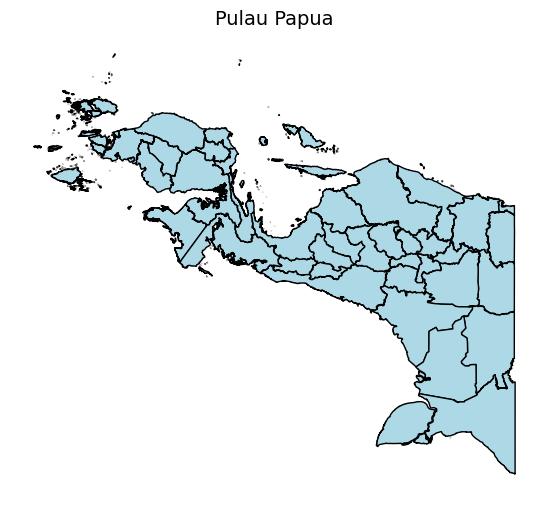

In [4]:
gdf.plot(figsize=(10, 6), edgecolor="black", facecolor="lightblue")
plt.title("Pulau Papua", fontsize=14)
plt.axis("off")


plt.show()

# Eksplorasi

1. Sebaran Persentase miskin Pulau Papua

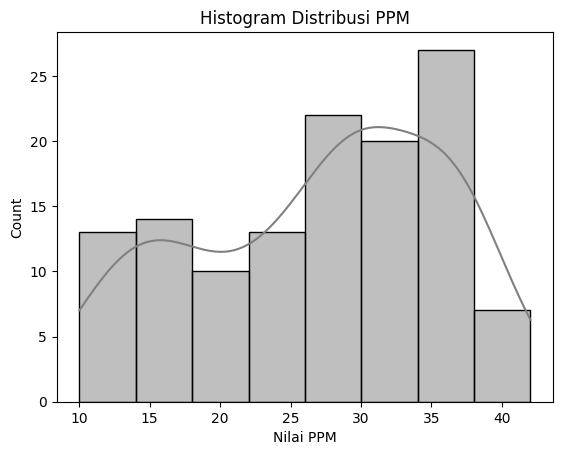

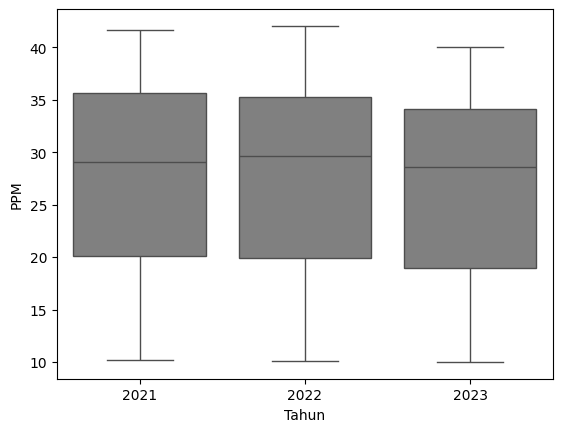

In [5]:
#histogram
sns.histplot(data=ppm_gab, x="PPM", kde=True, color="gray")

plt.xlabel("Nilai PPM")
plt.title("Histogram Distribusi PPM")

plt.savefig("Histogram_PPM.png", dpi=300, bbox_inches="tight")
plt.show()

#boxplot
sns.boxplot(
    x="Tahun", 
    y="PPM", 
    data=ppm_gab, 
    color="grey"
)
plt.savefig("Boxplot PPM")

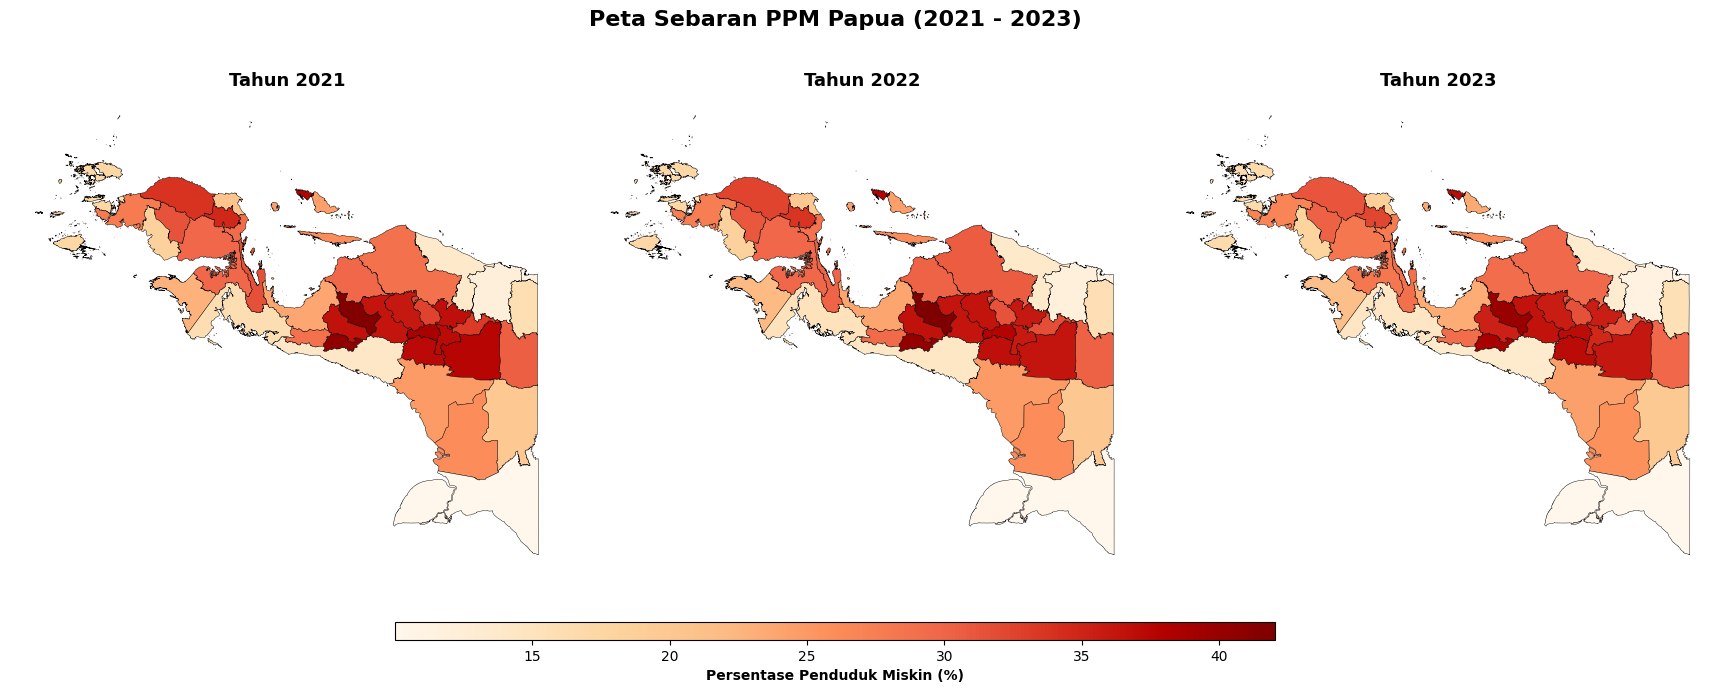

In [6]:

ppm_long = pd.melt(
    ppm, 
    id_vars=["Wilayah"],  # Sesuai dengan nama kolom di CSV Anda
    value_vars=["2021", "2022", "2023"], 
    var_name="Tahun", 
    value_name="PPM"
)

kolom_geojson = "WADMKK" 

gdf_merged = gdf.merge(
    ppm_long, 
    left_on=kolom_geojson, 
    right_on="Wilayah", 
    how="left"
)

vmin = gdf_merged["PPM"].min()
vmax = gdf_merged["PPM"].max()

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
tahun_list = ["2021", "2022", "2023"]

for ax, tahun in zip(axes, tahun_list):
    data_tahun = gdf_merged[gdf_merged["Tahun"] == tahun]
    
    # Plot Peta
    data_tahun.plot(
        ax=ax,
        column="PPM",
        cmap="OrRd",
        vmin=vmin,
        vmax=vmax,
        edgecolor="black",
        linewidth=0.3,
        missing_kwds={"color": "lightgrey", "label": "Data Tidak Ada"},
        aspect="auto"
    )
    
    for _, row in data_tahun.iterrows():
        if row.geometry is not None and not row.geometry.is_empty:
            centroid = row.geometry.representative_point()
            
            # Format teks nilai
            val_str = f"{row['PPM']:.1f}%" if pd.notnull(row['PPM']) else "-"
            nama_wilayah = row[kolom_geojson]
            
    ax.set_title(f"Tahun {tahun}", fontsize=13, fontweight="bold")
    ax.axis("off")

cax = fig.add_axes([0.3, 0.08, 0.4, 0.025])
sm = plt.cm.ScalarMappable(cmap="OrRd", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
cbar.set_label("Persentase Penduduk Miskin (%)", fontsize=10, fontweight="bold")

fig.suptitle("Peta Sebaran PPM Papua (2021 - 2023)", fontsize=16, fontweight="bold", y=0.98)
plt.subplots_adjust(bottom=0.15, wspace=0.04)
plt.savefig("Peta_Sebaran_PPM_3Tahun.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:

#TOP 10 WILAYAH DENGAN PPM TERTINGGI PER TAHUN
print("=" * 75)
print("       TOP 10 KABUPATEN/KOTA DENGAN PPM TERTINGGI PER TAHUN")
print("=" * 75)

for thn in ["2021", "2022", "2023"]:
    top_thn = (
        ppm_gab[ppm_gab["Tahun"] == thn]
        .sort_values(by="PPM", ascending=False)
        .head(10)
    )
    print(f"\n--- TAHUN {thn} ---")
    print(
        top_thn[["Wilayah", "PPM"]].to_string(index=False, formatters={"PPM": "{:.2f}%".format})
    )


# RATA-RATA PPM TERINGGI PERIODE 2021-2023 (KONSISTENSI)
ppm_avg = (
    ppm_gab.groupby("Wilayah")["PPM"]
    .mean()
    .reset_index()
    .rename(columns={"PPM": "Rata_Rata_PPM"})
)
ppm_avg_sorted = ppm_avg.sort_values(by="Rata_Rata_PPM", ascending=False)

print("\n" + "=" * 75)
print("  TOP 10 WILAYAH DENGAN RATA-RATA PPM TERTINGGI (2021-2023)")
print("=" * 75)
print(
    ppm_avg_sorted.head(10).to_string(
        index=False, formatters={"Rata_Rata_PPM": "{:.2f}%".format}
    )
)

ppm_matrix = ppm.copy()
ppm_matrix["Rata_Rata"] = ppm_matrix[["2021", "2022", "2023"]].mean(axis=1)
ppm_matrix_sorted = ppm_matrix.sort_values(by="Rata_Rata", ascending=False)

ppm_matrix_sorted.to_csv("ringkasan_ppm_tertinggi_2021_2023.csv", index=False)


       TOP 10 KABUPATEN/KOTA DENGAN PPM TERTINGGI PER TAHUN

--- TAHUN 2021 ---
         Wilayah    PPM
      Intan Jaya 41.66%
          Deiyai 40.59%
      Lanny Jaya 38.73%
         Supiori 37.91%
        Yahukimo 37.64%
           Nduga 37.18%
      Jayawijaya 37.09%
Mamberamo Tengah 36.76%
          Paniai 36.59%
          Puncak 36.26%

--- TAHUN 2022 ---
         Wilayah    PPM
      Intan Jaya 42.03%
          Deiyai 40.31%
      Lanny Jaya 37.76%
         Supiori 37.70%
           Nduga 36.73%
          Paniai 36.63%
     Puncak Jaya 36.30%
          Puncak 36.25%
        Yahukimo 36.21%
Mamberamo Tengah 35.92%

--- TAHUN 2023 ---
         Wilayah    PPM
      Intan Jaya 40.01%
          Deiyai 38.66%
           Nduga 37.09%
         Supiori 36.99%
      Lanny Jaya 36.94%
          Puncak 36.44%
        Yahukimo 36.08%
     Puncak Jaya 35.60%
Mamberamo Tengah 35.42%
          Paniai 35.39%

  TOP 10 WILAYAH DENGAN RATA-RATA PPM TERTINGGI (2021-2023)
         Wilayah Rata_Rata_

# Uji Morlan

In [8]:

gdf = gdf[gdf.geometry.notnull() & ~gdf.is_empty].copy()


# Melt Data
ppm_long = pd.melt(
    ppm, 
    id_vars=["Wilayah"], 
    value_vars=["2021", "2022", "2023"], 
    var_name="Tahun", 
    value_name="PPM"
)

# Merge ke GeoJSON (Gunakan 'WADMKK' untuk Kabupaten / 'WADMPR' untuk Provinsi)
kolom_geojson = "WADMKK"
gdf_merged = gdf.merge(ppm_long, left_on=kolom_geojson, right_on="Wilayah", how="left")

#2023
data_2023 = gdf_merged[gdf_merged["Tahun"] == "2023"].dropna(subset=["PPM"]).copy()
data_2023 = data_2023.reset_index(drop=True)


# HITUNG MATRIKS BOBOT SPASIAL (SPATIAL WEIGHTS)

# Menggunakan Matriks Tetangga Queen (bersentuhan di sisi maupun sudut)
w = Queen.from_dataframe(data_2023, use_index=False)
w.transform = 'R'  # Row-standardized matrix

# 3. GLOBAL MORAN'S I TEST

y = data_2023["PPM"].values
moran = Moran(y, w)

print("="*40)
print("     HASIL UJI GLOBAL MORAN'S I     ")
print("="*40)
print(f"Nilai Moran's I (I)   : {moran.I:.4f}")
print(f"E[I] (Nilai Harapan)  : {moran.EI:.4f}")
print(f"P-value (p_norm)      : {moran.p_norm:.4f}")
print(f"P-value Permutasi (p_sim): {moran.p_sim:.4f}")
print("="*40)

# Intrepretasi
if moran.p_sim < 0.05:
    if moran.I > moran.EI:
        print("Kesimpulan: Terdapat Autokorelasi Spasial POSITIF signifikan (Pola Mengelompok / Clustered).")
    else:
        print("Kesimpulan: Terdapat Autokorelasi Spasial NEGATIF signifikan (Pola Menyebar / Dispersed).")
else:
    print("Kesimpulan: Tidak terdapat Autokorelasi Spasial yang signifikan (Pola Acak / Random).")


c:\Users\Krist\AppData\Local\Programs\Python\Python313\Lib\site-packages\libpysal\weights\contiguity.py:354: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There is 1 island with id: 3.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 3, ' is an island (no neighbors)')
     HASIL UJI GLOBAL MORAN'S I     
Nilai Moran's I (I)   : 0.2151
E[I] (Nilai Harapan)  : -0.0244
P-value (p_norm)      : 0.0326
P-value Permutasi (p_sim): 0.0300
Kesimpulan: Terdapat Autokorelasi Spasial POSITIF signifikan (Pola Mengelompok / Clustered).


# Prapemrosesan Data (Analisis GWR)

1. Standardisasi X dan Y

In [ ]:

# 1. Merge ke Panel & GeoJSON
df_panel = (
    ppm_gab.merge(rls_gab, on=["Wilayah", "Tahun"])
    .merge(sts_gab, on=["Wilayah", "Tahun"])
    .merge(ppk_gab, on=["Wilayah", "Tahun"])
)

kolom_geojson = "WADMKK"
gdf_panel = gdf.merge(
    df_panel, left_on=kolom_geojson, right_on="Wilayah", how="inner"
)

data_gwr_per_tahun = {}
daftar_tahun = ["2021", "2022", "2023"]

for thn in daftar_tahun:
    
    gdf_thn = (
        gdf_panel[gdf_panel["Tahun"] == thn]
        .copy()
        .dropna(subset=["PPM", "RLS", "STS", "PPK"])
        .reset_index(drop=True)
    )
    centroids = gdf_thn.geometry.representative_point()
    coords = np.array(list(zip(centroids.x, centroids.y)))

    y = gdf_thn["PPM"].values.reshape((-1, 1))
    X = gdf_thn[["RLS", "STS", "PPK"]].values

    # Standardisasi
    y_std = (y - y.mean(axis=0)) / y.std(axis=0)
    X_std = (X - X.mean(axis=0)) / X.std(axis=0)

    
    data_gwr_per_tahun[thn] = {
        "gdf": gdf_thn,
        "coords": coords,
        "y_std": y_std,
        "X_std": X_std,
    }

    print(f"==== Koefisien Tahun {thn} ====")
    print(f"   -> Total Wilayah Teranalisis (N) : {len(gdf_thn)}")
    print(f"   -> Ukuran Matriks Coords         : {coords.shape}")
    print(f"   -> Ukuran Matriks Y (y_std)      : {y_std.shape}")
    print(f"   -> Ukuran Matriks X (X_std)      : {X_std.shape}\n")

==== Koefisien Tahun 2021 ====
   -> Total Wilayah Teranalisis (N) : 42
   -> Bentuk Matriks Coords         : (42, 2)
   -> Bentuk Matriks Y (y_std)      : (42, 1)
   -> Bentuk Matriks X (X_std)      : (42, 3)

==== Koefisien Tahun 2022 ====
   -> Total Wilayah Teranalisis (N) : 42
   -> Bentuk Matriks Coords         : (42, 2)
   -> Bentuk Matriks Y (y_std)      : (42, 1)
   -> Bentuk Matriks X (X_std)      : (42, 3)

==== Koefisien Tahun 2023 ====
   -> Total Wilayah Teranalisis (N) : 42
   -> Bentuk Matriks Coords         : (42, 2)
   -> Bentuk Matriks Y (y_std)      : (42, 1)
   -> Bentuk Matriks X (X_std)      : (42, 3)



2. Uji Asumsi

In [ ]:
daftar_tahun = ["2021", "2022", "2023"]

print("=" * 70)
print("       TAHAP 3: UJI ASUMSI KELAYAKAN LENGKAP MODEL OLS / GWR        ")
print("=" * 70 + "\n")

for thn in daftar_tahun:
    print(f"======================== TAHUN {thn} ========================")

    # 1. Ambil data matriks & GeoDataFrame dari dictionary Tahap 2
    gdf_thn = data_gwr_per_tahun[thn]["gdf"]
    X_matriks = data_gwr_per_tahun[thn]["X_std"]
    y_matriks = data_gwr_per_tahun[thn]["y_std"]

    # 2. Fit Model OLS biasa untuk evaluasi residual
    X_ols = sm.add_constant(X_matriks)
    model_ols = sm.OLS(y_matriks, X_ols).fit()
    residual = model_ols.resid.flatten()

  
    # A. UJI MULTIKOLINEARITAS GLOBAL (VIF)

    df_X = pd.DataFrame(X_matriks, columns=["RLS", "STS", "PPK"])
    vif_df = pd.DataFrame()
    vif_df["Variabel"] = df_X.columns
    vif_df["VIF"] = [
        variance_inflation_factor(df_X.values, i) for i in range(df_X.shape[1])
    ]

    print("[1] UJI MULTIKOLINEARITAS (VIF):")
    print(vif_df.to_string(index=False))

    if (vif_df["VIF"] < 5).all():
        print("    -> STATUS: AMAN (Semua VIF < 5, bebas multikolinearitas).")
    else:
        print(
            "    -> PERHATIAN: Ada variabel dengan VIF >= 5 (Masih toleransi jika VIF < 10)."
        )

    # B. UJI OTOKORELASI SPASIAL RESIDUAL OLS (MORAN'S I)
   
    spatial_weights = libpysal.weights.KNN.from_dataframe(gdf_thn, k=5)
    spatial_weights.transform = "R"
    moran_test = Moran(residual, spatial_weights)

    print("\n[2] UJI OTOKORELASI SPASIAL RESIDUAL (MORAN'S I):")
    print(f"    -> Indeks Moran's I : {moran_test.I:.4f}")
    print(f"    -> p-value          : {moran_test.p_norm:.4f}")

    if moran_test.p_norm < 0.05:
        print(
            "    -> STATUS: KELAYAKAN TERBUKTI (p-value < 0.05, terdapat otokorelasi spasial)."
        )
        print("    -> KESIMPULAN: OLS Gagal, WAJIB dilanjutkan ke GWR!")
    else:
        print(
            "    -> STATUS: Tidak terdeteksi otokorelasi spasial signifikan."
        )

    
    # C. UJI NORMALITAS RESIDUAL
   
    jb_stat, jb_pvalue = stats.jarque_bera(residual)
    sw_stat, sw_pvalue = stats.shapiro(residual)

    print("\n[3] UJI NORMALITAS RESIDUAL:")
    print(
        f"    a. Shapiro-Wilk Test : Statistic = {sw_stat:.4f}, p-value = {sw_pvalue:.4f}"
    )
    print(
        f"    b. Jarque-Bera Test  : Statistic = {jb_stat:.4f}, p-value = {jb_pvalue:.4f}"
    )

    if sw_pvalue > 0.05:
        print(
            "residual berdistribusi normal"
        )
    else:
        print(
            "residual tidak berdistribusi normal"
        )

    # -------------------------------------------------------------
    # D. UJI HETEROSKEDASTISITAS
    # -------------------------------------------------------------
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(residual, X_ols)

    print("\n[4] UJI HETEROSKEDASTISITAS (Breusch-Pagan Test):")
    print(f"    -> Lagged Multiplier (LM) Statistic : {lm_stat:.4f}")
    print(f"    -> p-value                          : {lm_pvalue:.4f}")

    if lm_pvalue < 0.05:
        print(
            " STATUS: TERJADI HETEROSKEDASTISITAS"
        )
        print(
            "Mengindikasikan adanya efek variasi spasial yang tepat dimodelkan GWR."
        )
    else:
        print(
            "HOMOSKEDASTIS"
        )

    print("-" * 70 + "\n")

       TAHAP 3: UJI ASUMSI KELAYAKAN LENGKAP MODEL OLS / GWR        

======================== TAHUN 2021 ========================
[1] UJI MULTIKOLINEARITAS (VIF):
Variabel      VIF
     RLS 7.403817
     STS 4.711099
     PPK 2.877258
    -> PERHATIAN: Ada variabel dengan VIF >= 5 (Masih toleransi jika VIF < 10).

[2] UJI OTOKORELASI SPASIAL RESIDUAL (MORAN'S I):
    -> Indeks Moran's I : 0.1585
    -> p-value          : 0.0277
    -> STATUS: KELAYAKAN TERBUKTI (p-value < 0.05, terdapat otokorelasi spasial).
    -> KESIMPULAN: OLS Gagal, WAJIB dilanjutkan ke GWR!

[3] UJI NORMALITAS RESIDUAL:
    a. Shapiro-Wilk Test : Statistic = 0.9817, p-value = 0.7281
    b. Jarque-Bera Test  : Statistic = 0.6681, p-value = 0.7160
    -> STATUS: MEMENUHI ASUMSI (p-value > 0.05, residual berdistribusi NORMAL).

[4] UJI HETEROSKEDASTISITAS (Breusch-Pagan Test):
    -> Lagged Multiplier (LM) Statistic : 5.1149
    -> p-value                          : 0.1636
    -> STATUS: HOMOSKEDASTIS (p-value >= 0

# Matriks Pembobot Jarak

In [ ]:

print("=" * 75)
print("     TAHAP 4: PENCARIAN BANDWIDTH OPTIMAL (Sel_BW) - FIXED FINAL")
print("=" * 75 + "\n")

bandwidth_per_tahun = {}
daftar_tahun = "2023"
for thn in daftar_tahun:
    print(f"======================== TAHUN {thn} ========================")

    coords = data_gwr_per_tahun[thn]["coords"]
    y_std = data_gwr_per_tahun[thn]["y_std"]
    X_std = data_gwr_per_tahun[thn]["X_std"]

    # batas maksimum tetangga (N - 1)
    N = len(coords)
    max_k = N - 1

    # 3. Inisialisasi Sel_BW standar
    bw_selector = Sel_BW(
        coords, y_std, X_std, kernel="bisquare", fixed=False, spherical=False
    )

    opt_bw = bw_selector.search(
        criterion="AICc",
        bw_min=2,      
        bw_max=max_k   
    )

    bandwidth_per_tahun[thn] = {
        "selector": bw_selector,
        "opt_bw": opt_bw,
    }

    print(f" Jumlah Wilayah (N)       : {N} kabupaten/kota")
    print(f" Batas Pencarian Bandwidth: 2 s.d. {max_k} tetangga")
    print(f" Bandwidth Optimal (K-NN) : {opt_bw} tetangga terdekat")
    print("-" * 75 + "\n")

     TAHAP 4: PENCARIAN BANDWIDTH OPTIMAL (Sel_BW) - FIXED FINAL

======================== TAHUN 2021 ========================
   -> Jumlah Wilayah (N)       : 42 kabupaten/kota
   -> Batas Pencarian Bandwidth: 2 s.d. 41 tetangga
   -> Jenis Kernel             : Adaptive Bisquare
   -> Bandwidth Optimal (K-NN) : 28.0 tetangga terdekat
---------------------------------------------------------------------------

======================== TAHUN 2022 ========================
   -> Jumlah Wilayah (N)       : 42 kabupaten/kota
   -> Batas Pencarian Bandwidth: 2 s.d. 41 tetangga
   -> Jenis Kernel             : Adaptive Bisquare
   -> Bandwidth Optimal (K-NN) : 28.0 tetangga terdekat
---------------------------------------------------------------------------

======================== TAHUN 2023 ========================
   -> Jumlah Wilayah (N)       : 42 kabupaten/kota
   -> Batas Pencarian Bandwidth: 2 s.d. 41 tetangga
   -> Jenis Kernel             : Adaptive Bisquare
   -> Bandwidth Optimal

In [ ]:
print("=" * 75)
print("     DETAIL PUSAT BANDWIDTH DAN DAFTAR 28 TETANGGANYA")
print("=" * 75 + "\n")

# Dict untuk menyimpan tabel detail pusat per tahun
df_detail_pusat_per_tahun = {}
daftar_tahun = "2023"
for thn in daftar_tahun:
    coords = data_gwr_per_tahun[thn]["coords"]
    opt_bw = int(bandwidth_per_tahun[thn]["opt_bw"])  # Misal: 28
    N = len(coords)

    #Hitung matriks jarak Euclidean antar kabupaten (N x N)
    dmat = cdist(coords, coords, metric="euclidean")

    # Urutkan indeks & Jarak
    indeks_terurut = np.argsort(dmat, axis=1)
    jarak_terurut = np.sort(dmat, axis=1)
    data_pusat = []
    for i in range(N):
        # Kabupaten i sebagai PUSAT
        radius_maks = jarak_terurut[i, opt_bw - 1]  # Jarak ke tetangga ke-28
        tetangga_28 = indeks_terurut[i, :opt_bw]  # Indeks 28 tetangga terdekat

        data_pusat.append(
            {
                "Kabupaten_Pusat_Idx": i,
                "Koordinat_X": coords[i, 0],
                "Koordinat_Y": coords[i, 1],
                "Radius_Bandwidth_Terluar": radius_maks,
                "Daftar_28_Tetangga_Idx": tetangga_28.tolist(),
            }
        )

    df_pusat = pd.DataFrame(data_pusat)
    df_detail_pusat_per_tahun[thn] = df_pusat

    print(f"======================== TAHUN {thn} ========================")
    print(f"Total Kabupaten Pusat (N)       : {N} wilayah")
    print(f"Jumlah Tetangga Terdekat (K-NN) : {opt_bw} tetangga")
    print(
        f"Radius Terluar Paling Kecil     : {df_pusat['Radius_Bandwidth_Terluar'].min():,.2f} unit"
    )
    print(
        f"Radius Terluar Paling Besar     : {df_pusat['Radius_Bandwidth_Terluar'].max():,.2f} unit"
    )
    print("-" * 75 + "\n")


     DETAIL PUSAT BANDWIDTH DAN DAFTAR 28 TETANGGANYA

======================== TAHUN 2021 ========================
Total Kabupaten Pusat (N)       : 42 wilayah
Jumlah Tetangga Terdekat (K-NN) : 28 tetangga
Radius Terluar Paling Kecil     : 3.43 unit
Radius Terluar Paling Besar     : 8.54 unit
---------------------------------------------------------------------------

======================== TAHUN 2022 ========================
Total Kabupaten Pusat (N)       : 42 wilayah
Jumlah Tetangga Terdekat (K-NN) : 28 tetangga
Radius Terluar Paling Kecil     : 3.43 unit
Radius Terluar Paling Besar     : 8.54 unit
---------------------------------------------------------------------------

======================== TAHUN 2023 ========================
Total Kabupaten Pusat (N)       : 42 wilayah
Jumlah Tetangga Terdekat (K-NN) : 28 tetangga
Radius Terluar Paling Kecil     : 3.43 unit
Radius Terluar Paling Besar     : 8.54 unit
-----------------------------------------------------------------------

Visualisasi bandwidth

C:\Users\Krist\AppData\Local\Temp\ipykernel_9428\573245023.py:89: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(


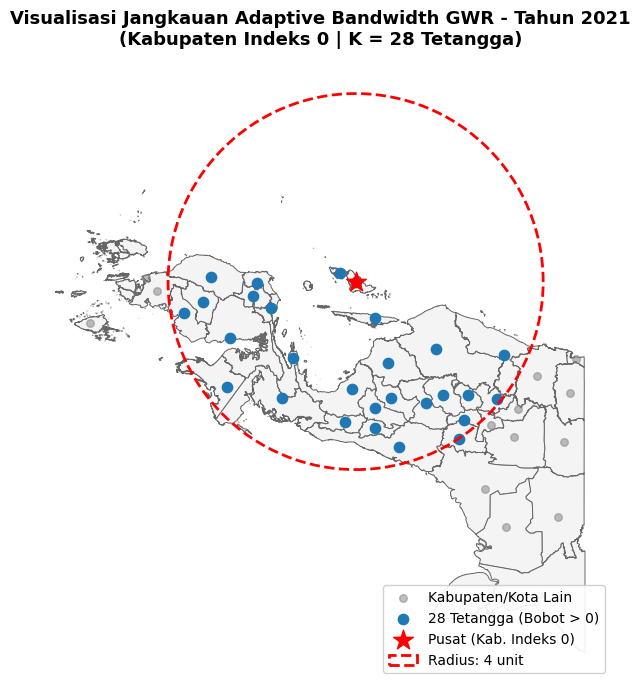

In [145]:
# 2. TENTUKAN TAHUN FOKUS
thn = "2021"

# Pilih kabupaten pusat yang ingin dilihat (Contoh: Kabupaten Indeks ke-0)
idx_pusat = 0

# Ambil data dari dictionary Tahap 4 Anda
coords_thn = data_gwr_per_tahun[thn]["coords"]
opt_bw_thn = int(bandwidth_per_tahun[thn]["opt_bw"])

# 3. Hitung Matriks Jarak Euclidean & Urutkan Tetangga
dmat = cdist(coords_thn, coords_thn, metric="euclidean")
indeks_terurut = np.argsort(dmat, axis=1)
jarak_terurut = np.sort(dmat, axis=1)

# Ekstraksi Koordinat Pusat & Radius Bandwidth
pusat_x = coords_thn[idx_pusat, 0]
pusat_y = coords_thn[idx_pusat, 1]
radius_thn = jarak_terurut[idx_pusat, opt_bw_thn - 1]

# Ambil daftar indeks tetangga terdekat (K-NN)
daftar_tetangga_idx = indeks_terurut[idx_pusat, :opt_bw_thn]
coords_tetangga = coords_thn[daftar_tetangga_idx]

# 4. PLOTTING PETA TAHUN 2021
fig, ax = plt.subplots(figsize=(10, 7))

# A. Plot Batas Wilayah Papua (GeoJSON)
gdf.plot(
    ax=ax,
    color="#f4f4f4",
    edgecolor="#666666",
    linewidth=0.7,
    label="Batas Wilayah",
)

# B. Plot Seluruh Kabupaten/Kota
ax.scatter(
    coords_thn[:, 0],
    coords_thn[:, 1],
    color="gray",
    s=30,
    alpha=0.5,
    label="Kabupaten/Kota Lain",
)

# C. Highlight Tetangga Terdekat (Bobot > 0)
ax.scatter(
    coords_tetangga[:, 0],
    coords_tetangga[:, 1],
    color="#1f77b4",
    s=55,
    zorder=4,
    label=f"{opt_bw_thn} Tetangga (Bobot > 0)",
)

# D. Titik Pusat Utama (Bintang Merah)
ax.scatter(
    pusat_x,
    pusat_y,
    color="red",
    marker="*",
    s=220,
    zorder=6,
    label=f"Pusat (Kab. Indeks {idx_pusat})",
)

# E. Lingkaran Radius Bandwidth
lingkaran = plt.Circle(
    (pusat_x, pusat_y),
    radius_thn,
    color="red",
    fill=False,
    linestyle="--",
    linewidth=2,
    zorder=5,
    label=f"Radius: {radius_thn:,.0f} unit",
)
ax.add_patch(lingkaran)

# Pengaturan Judul & Legenda
ax.set_title(
    f"Visualisasi Jangkauan Adaptive Bandwidth GWR - Tahun {thn}\n(Kabupaten Indeks {idx_pusat} | K = {opt_bw_thn} Tetangga)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_axis_off()
ax.legend(
    loc="lower right",
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    fontsize=10,
)

plt.tight_layout()

# Simpan gambar kualitas tinggi untuk paper (Opsional)
# plt.savefig("Peta_Bandwidth_Papua_2021.png", dpi=300, bbox_inches='tight')
plt.savefig("Visualisasi Bandwidth")
plt.show()

# Pemodelan 

In [ ]:
from mgwr.gwr import GWR

print("=" * 75)
print("                  TAHAP 5: FITTING MODEL GWR                     ")
print("=" * 75 + "\n")

hasil_gwr_per_tahun = {}

for thn in daftar_tahun:
    print(f"======================== TAHUN {thn} ========================")

    coords = data_gwr_per_tahun[thn]["coords"]
    y_std = data_gwr_per_tahun[thn]["y_std"]
    X_std = data_gwr_per_tahun[thn]["X_std"]
    opt_bw = bandwidth_per_tahun[thn]["opt_bw"]

    # Fit GWR menggunakan Bandwidth Optimal (28 tetangga)
    gwr_model = GWR(
        coords, y_std, X_std, bw=opt_bw, kernel="bisquare", fixed=False
    )
    gwr_results = gwr_model.fit()

    hasil_gwr_per_tahun[thn] = {
        "model": gwr_model,
        "results": gwr_results,
        "bandwidth": opt_bw,
    }

    print(f"Bandwidth Terpakai        : {opt_bw} tetangga terdekat")
    print(f"R-squared (GWR)          : {gwr_results.R2:.4f}")
    print(f"Adjusted R-squared (GWR) : {gwr_results.adj_R2:.4f}")
    print(f"AICc GWR                 : {gwr_results.aicc:.4f}")
    print("-" * 75 + "\n")

                  TAHAP 5: FITTING MODEL GWR                     

======================== TAHUN 2021 ========================
   -> Bandwidth Terpakai        : 28.0 tetangga terdekat
   -> R-squared (GWR)          : 0.8277
   -> Adjusted R-squared (GWR) : 0.7631
   -> AICc GWR                 : 80.8559
   -> STATUS ESTIMASI          : SUKSES MEMODELKAN PARAMETER LOKAL
---------------------------------------------------------------------------

======================== TAHUN 2022 ========================
   -> Bandwidth Terpakai        : 28.0 tetangga terdekat
   -> R-squared (GWR)          : 0.8081
   -> Adjusted R-squared (GWR) : 0.7367
   -> AICc GWR                 : 85.0714
   -> STATUS ESTIMASI          : SUKSES MEMODELKAN PARAMETER LOKAL
---------------------------------------------------------------------------

======================== TAHUN 2023 ========================
   -> Bandwidth Terpakai        : 28.0 tetangga terdekat
   -> R-squared (GWR)          : 0.8228
   -> Adj

# Ekspor Koefisien Lokal

In [ ]:

list_df_hasil = []

for thn in daftar_tahun:
    # 1. Ambil data GeoDataFrame & hasil GWR
    gdf_thn = data_gwr_per_tahun[thn]["gdf"]
    gwr_res = hasil_gwr_per_tahun[thn]["results"]

    # 2. Reset indeks nama wilayah agar dipastikan tepat 42 elemen berseri (0 s.d 41)
    wilayah_series = gdf_thn["Wilayah"].reset_index(drop=True)
    N = len(wilayah_series)  # N = 42

    # 3. Ambil matriks params, tvalues, dan localR2
    params = np.array(gwr_res.params)
    tvalues = np.array(gwr_res.tvalues)
    local_r2 = np.array(gwr_res.localR2).reshape(-1)

    # 4. Buat DataFrame kosong lalu isi kolom satu per satu
    df_temp = pd.DataFrame()
    df_temp["Tahun"] = [str(thn)] * N
    df_temp["Wilayah"] = wilayah_series

    # Koefisien Beta
    df_temp["Intercept_Beta0"] = params[:N, 0]
    df_temp["Beta_RLS"] = params[:N, 1]
    df_temp["Beta_STS"] = params[:N, 2]
    df_temp["Beta_PPK"] = params[:N, 3]

    # Nilai t-statistik lokal
    df_temp["t_Intercept"] = tvalues[:N, 0]
    df_temp["t_RLS"] = tvalues[:N, 1]
    df_temp["t_STS"] = tvalues[:N, 2]
    df_temp["t_PPK"] = tvalues[:N, 3]

    # Local R2
    df_temp["Local_R2"] = local_r2[:N]

    # Condition Number 
    if hasattr(gwr_res, "CCT") and gwr_res.CCT is not None:
        cct = np.array(gwr_res.CCT).reshape(-1)
        df_temp["Condition_Number"] = cct[:N]

    list_df_hasil.append(df_temp)

# 5. Gabungkan seluruh tahun (2021, 2022, 2023) menjadi satu DataFrame
df_ekspor_gwr = pd.concat(list_df_hasil, ignore_index=True)

# 6. Simpan ke file CSV
nama_file_csv = "koefisien_lokal_gwr_2021_2023.csv"
df_ekspor_gwr.to_csv(nama_file_csv, index=False)


-> SUKSES! Total 126 baris data berhasil diekspor ke 'koefisien_lokal_gwr_2021_2023.csv'


# Visualisasi Koefisien

In [ ]:
df_gwr = pd.read_csv("koefisien_lokal_gwr_2021_2023.csv")
cmap_pilihan = "YlGnBu_r"
tahun_list = ["2021", "2022", "2023"]


1. Koefisien Rata-Rata Lama Sekolah

C:\Users\Krist\AppData\Local\Temp\ipykernel_9428\4014551146.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 0.95])


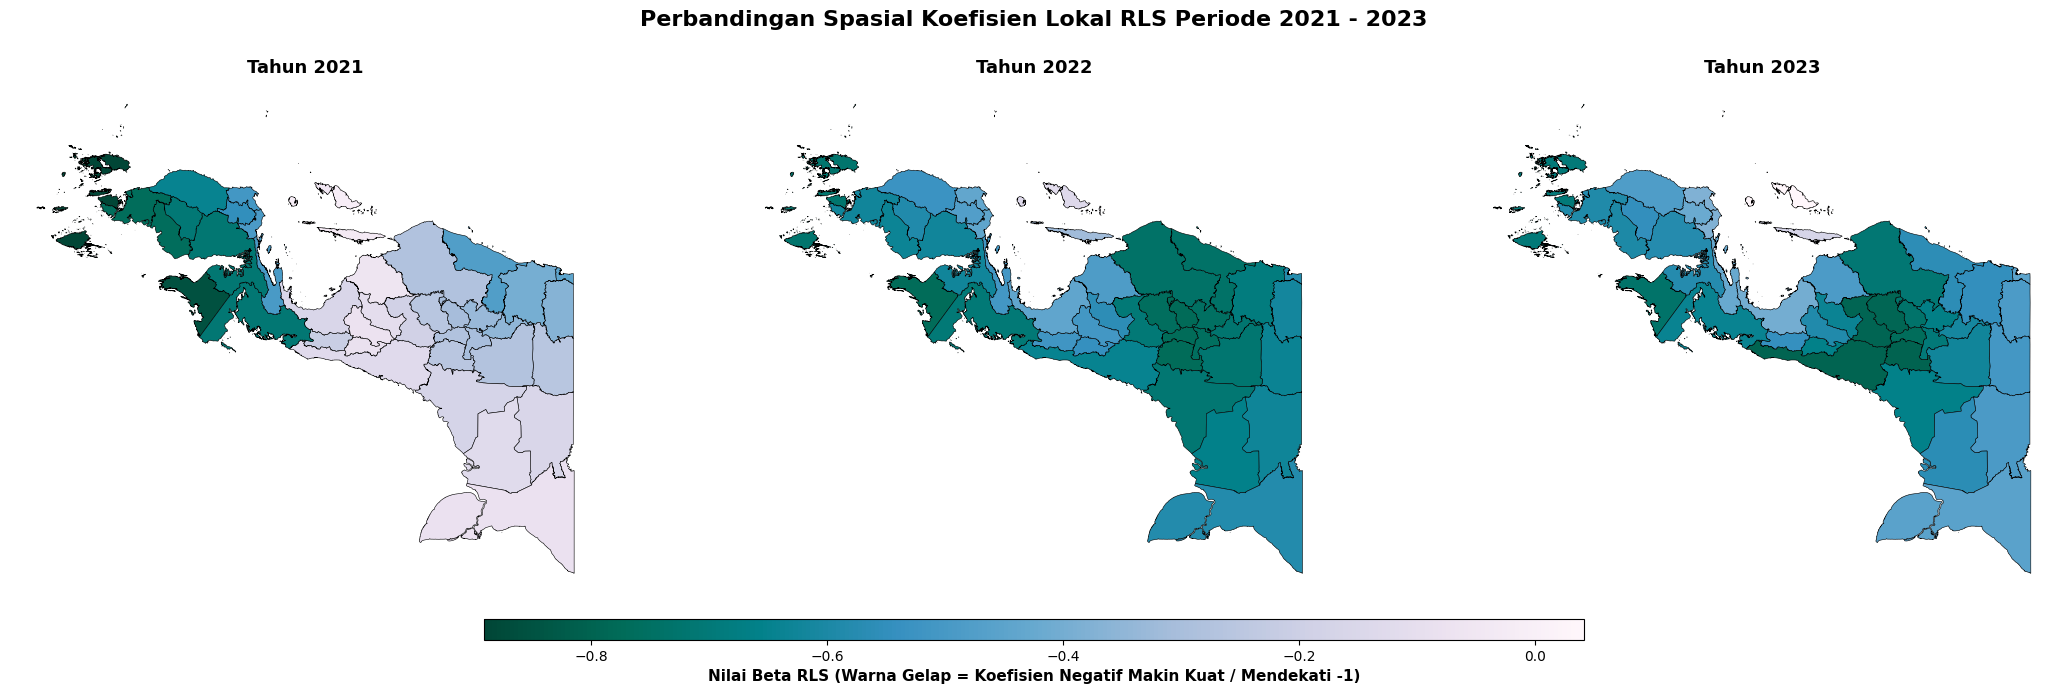

-> Berhasil! Peta disimpan dalam 'peta_spasial_beta_rls_2021_2023.png'


In [ ]:



# 2. Hitung nilai minimum dan maksimum global
vmin_rls = df_gwr["Beta_RLS"].min()
vmax_rls = df_gwr["Beta_RLS"].max()

# 3. Buat 1 Figur dengan 3 Subplot secara Horisontal (1 baris, 3 kolom)
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(
    "Perbandingan Spasial Koefisien Lokal RLS Periode 2021 - 2023",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

sm = None

for idx, thn in enumerate(tahun_list):
    ax = axes[idx]

    # Ambil GeoDataFrame dan merge data CSV
    gdf_thn = data_gwr_per_tahun[thn]["gdf"].copy()
    df_thn = df_gwr[df_gwr["Tahun"].astype(str) == str(thn)]
    gdf_mapped = gdf_thn.merge(df_thn, on="Wilayah")

    # Plot peta spasial polygon
    gdf_mapped.plot(
        column="Beta_RLS",
        cmap=cmap_pilihan,  # <--- Menggunakan Colormap Terbalik (_r)
        vmin=vmin_rls,
        vmax=vmax_rls,
        legend=False,
        edgecolor="black",
        linewidth=0.4,
        ax=ax,
    )

    if sm is None:
        sm = plt.cm.ScalarMappable(
            cmap=cmap_pilihan, norm=plt.Normalize(vmin=vmin_rls, vmax=vmax_rls)
        )

    ax.set_title(f"Tahun {thn}", fontsize=13, fontweight="bold")
    ax.set_axis_off()

# 4. Tambahkan 1 Colorbar Bersama di bawah
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label(
    "Nilai Beta RLS (Warna Gelap = Koefisien Negatif Makin Kuat / Mendekati -1)",
    fontsize=11,
    fontweight="bold",
)

plt.tight_layout(rect=[0, 0.12, 1, 0.95])
nama_file_peta = "peta_spasial_beta_rls_2021_2023.png"
plt.savefig(nama_file_peta, dpi=300, bbox_inches="tight")
plt.show()


2. Visualisasi Koefisien Sanitasi

C:\Users\Krist\AppData\Local\Temp\ipykernel_9428\88057962.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 0.95])


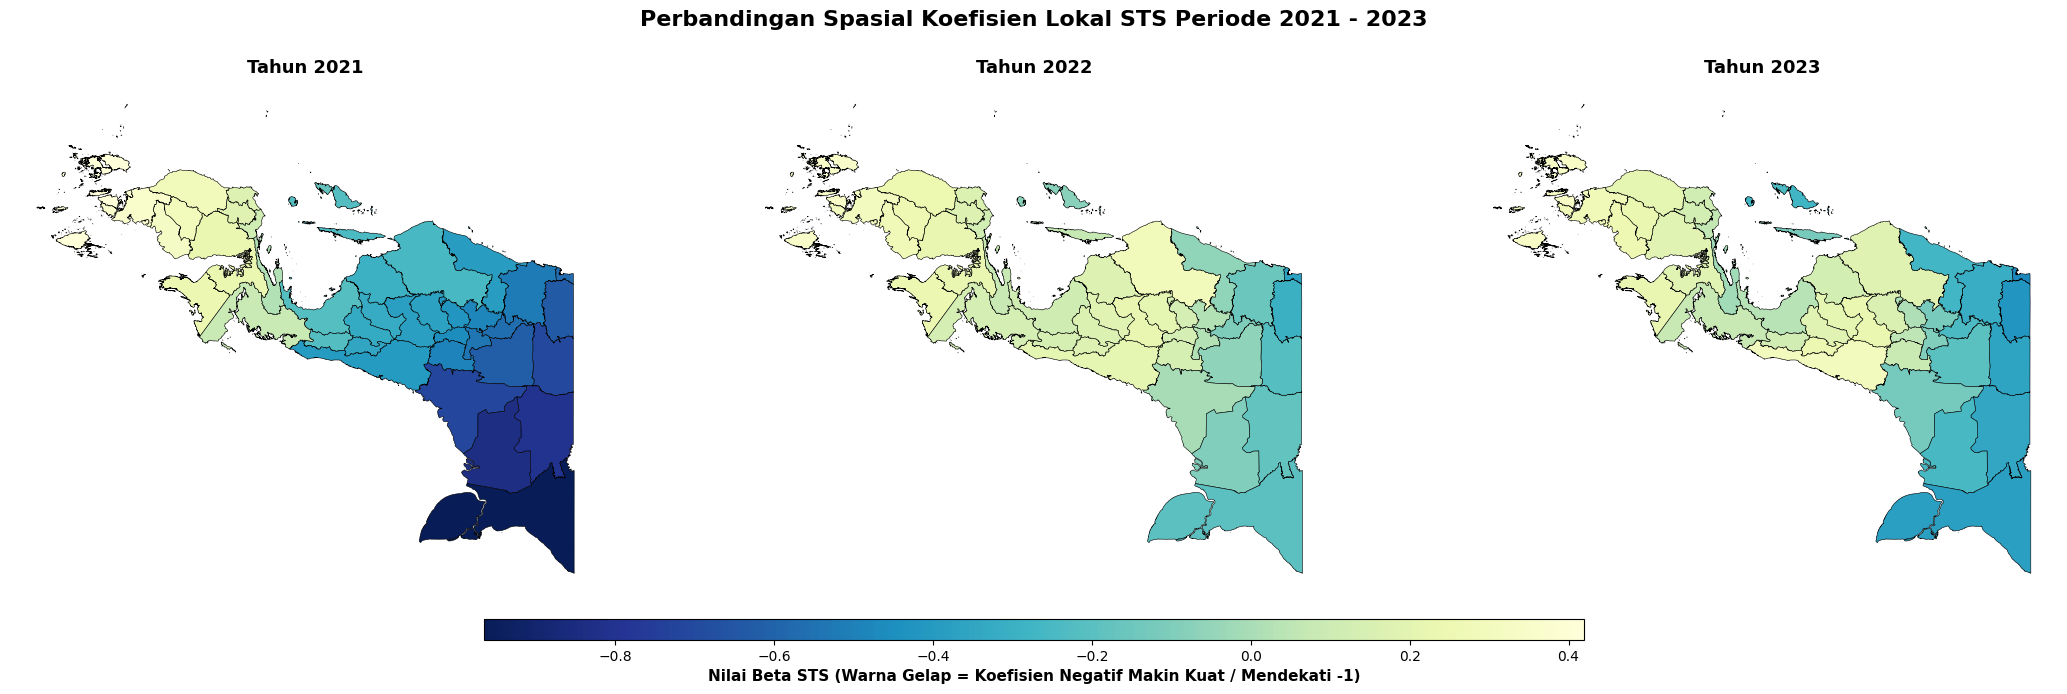

-> Berhasil! Peta perbandingan STS 3 tahun disimpan dalam 'peta_spasial_beta_sts_2021_2023.png'


In [ ]:
vmin_sts = df_gwr["Beta_STS"].min()
vmax_sts = df_gwr["Beta_STS"].max()

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(
    "Perbandingan Spasial Koefisien Lokal STS Periode 2021 - 2023",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
sm = None

# 4. Looping untuk setiap tahun
for idx, thn in enumerate(tahun_list):
    ax = axes[idx]

    
    gdf_thn = data_gwr_per_tahun[thn]["gdf"].copy()
    df_thn = df_gwr[df_gwr["Tahun"].astype(str) == str(thn)]
    gdf_mapped = gdf_thn.merge(df_thn, on="Wilayah")

   
    gdf_mapped.plot(
        column="Beta_STS",
        cmap=cmap_pilihan,  # <--- Skema terbalik: Gelap = mendekati -1, Terang = mendekati 0/positif
        vmin=vmin_sts,  # Batas bawah dikunci seragam
        vmax=vmax_sts,  # Batas atas dikunci seragam
        legend=False,  # Legend dimatikan per subplot
        edgecolor="black",
        linewidth=0.4,
        ax=ax,
    )

    
    if sm is None:
        sm = plt.cm.ScalarMappable(
            cmap=cmap_pilihan, norm=plt.Normalize(vmin=vmin_sts, vmax=vmax_sts)
        )

    ax.set_title(f"Tahun {thn}", fontsize=13, fontweight="bold")
    ax.set_axis_off()


cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label(
    "Nilai Beta STS (Warna Gelap = Koefisien Negatif Makin Kuat / Mendekati -1)",
    fontsize=11,
    fontweight="bold",
)

plt.tight_layout(rect=[0, 0.12, 1, 0.95])
nama_file_peta = "peta_spasial_beta_sts_2021_2023.png"
plt.savefig(nama_file_peta, dpi=300, bbox_inches="tight")
plt.show()


3. Visualisasi Koefisien Pengeluaran Per Kapita

C:\Users\Krist\AppData\Local\Temp\ipykernel_9428\1689139389.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 0.95])


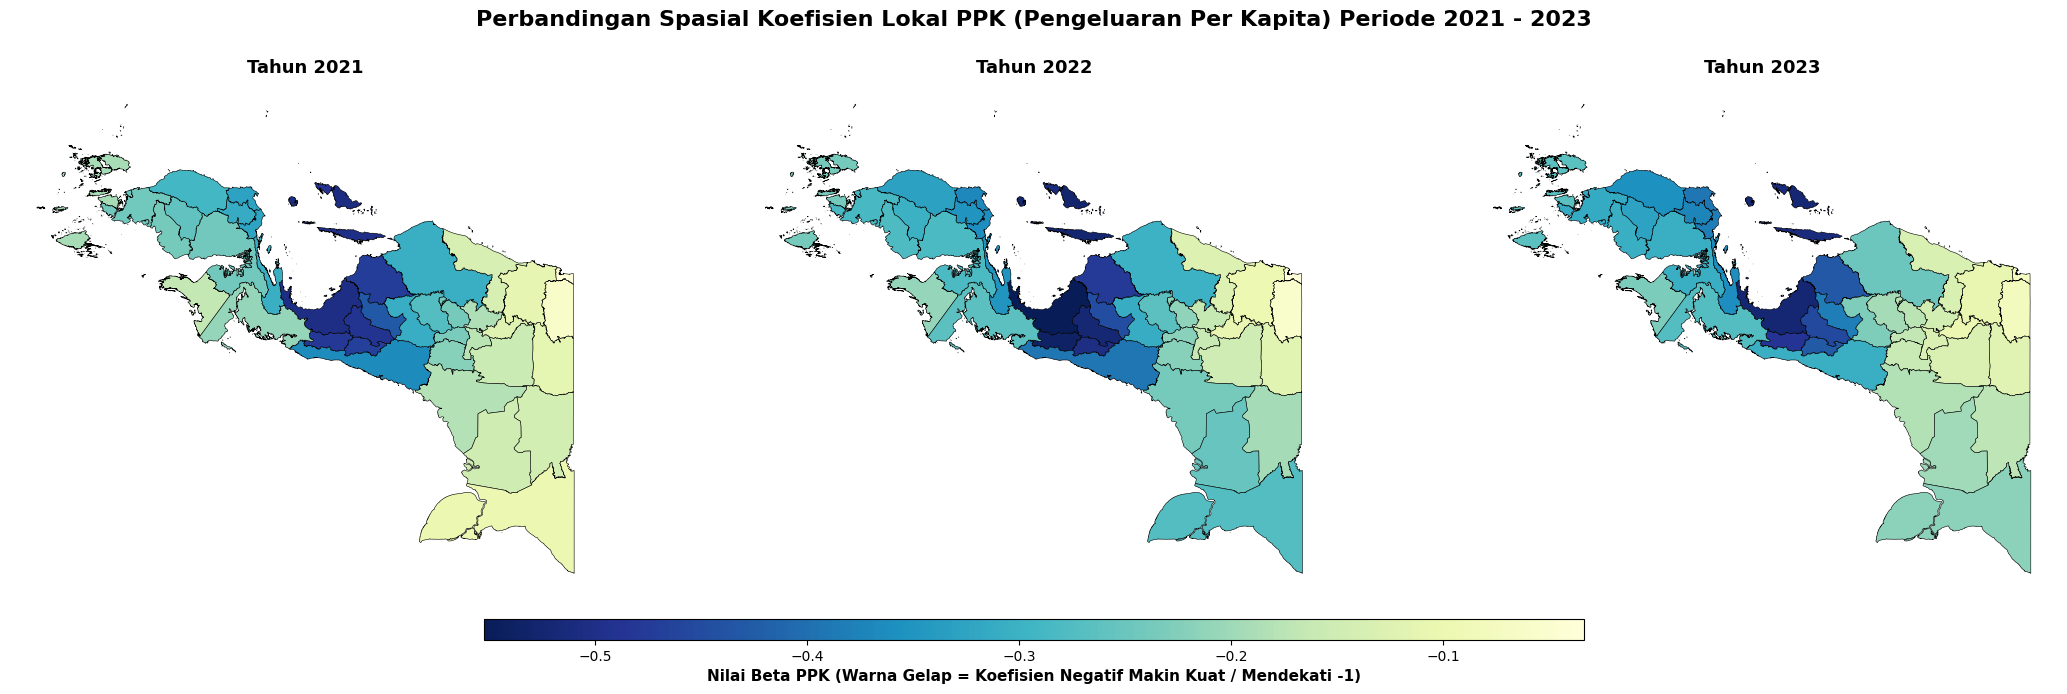

-> Berhasil! Peta perbandingan PPK 3 tahun disimpan dalam 'peta_spasial_beta_ppk_2021_2023.png'


In [ ]:
vmin_ppk = df_gwr["Beta_PPK"].min()
vmax_ppk = df_gwr["Beta_PPK"].max()

# 3. Buat 1 Figur dengan 3 Subplot Horisontal (1 baris, 3 kolom)
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(
    "Perbandingan Spasial Koefisien Lokal PPK (Pengeluaran Per Kapita) Periode 2021 - 2023",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
sm = None

for idx, thn in enumerate(tahun_list):
    ax = axes[idx]

   
    gdf_thn = data_gwr_per_tahun[thn]["gdf"].copy()
    df_thn = df_gwr[df_gwr["Tahun"].astype(str) == str(thn)]
    gdf_mapped = gdf_thn.merge(df_thn, on="Wilayah")

    
    gdf_mapped.plot(
        column="Beta_PPK",
        cmap=cmap_pilihan,  # <--- Skema terbalik: Gelap = mendekati -1, Terang = mendekati 0
        vmin=vmin_ppk,  # Batas bawah dikunci seragam
        vmax=vmax_ppk,  # Batas atas dikunci seragam
        legend=False,  # Legend dimatikan per subplot
        edgecolor="black",
        linewidth=0.4,
        ax=ax,
    )

   
    if sm is None:
        sm = plt.cm.ScalarMappable(
            cmap=cmap_pilihan, norm=plt.Normalize(vmin=vmin_ppk, vmax=vmax_ppk)
        )

    ax.set_title(f"Tahun {thn}", fontsize=13, fontweight="bold")
    ax.set_axis_off()

cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label(
    "Nilai Beta PPK (Warna Gelap = Koefisien Negatif Makin Kuat / Mendekati -1)",
    fontsize=11,
    fontweight="bold",
)

plt.tight_layout(rect=[0, 0.12, 1, 0.95])


nama_file_peta = "peta_spasial_beta_ppk_2021_2023.png"
plt.savefig(nama_file_peta, dpi=300, bbox_inches="tight")
plt.show()
